In [1]:
# STEP 1 : Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:
# STEP 2 : Load COVID Dataset
covid = pd.read_csv("data/raw/covid_confirmed.csv")
covid.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,209322,209340,209358,209362,209369,209390,209406,209436,209451,209451
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,334391,334408,334408,334427,334427,334427,334427,334427,334443,334457
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,271441,271448,271463,271469,271469,271477,271477,271490,271494,271496
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,47866,47875,47875,47875,47875,47875,47875,47875,47890,47890
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,105255,105277,105277,105277,105277,105277,105277,105277,105288,105288


In [9]:
# STEP 3 : Convert to long format
covid_long = covid.melt( id_vars = ["Province/State", "Country/Region", "Lat", "Long"], var_name = "Date", value_name = "Cases")

In [10]:
# STEP 4 : Clean and Filter India
covid_long["Date"] = pd.to_datetime(covid_long["Date"], format = "%m/%d/%y")
covid_india = covid_long[covid_long["Country/Region"] == "India"]

In [11]:
# STEP 5 : Create Daily Cases
covid_india = covid_india.groupby("Date")["Cases"].sum().reset_index()
covid_india["DailyCases"] = covid_india["Cases"].diff().fillna(0)
covid_india["DailyCases"] = covid_india["DailyCases"].clip(lower = 0)
covid_india["DailyCases"] = covid_india["DailyCases"].astype(int)

In [12]:
# STEP 6 : Convert to Monthly
covid_india["YearMonth"] = covid_india["Date"].dt.to_period("M")
covid_monthly = covid_india.groupby("YearMonth")["DailyCases"].sum().reset_index()

In [13]:
# STEP 7 : Load Mobility Dataset
cols = [ "country_region", "date", "retail_and_recreation_percent_change_from_baseline", "workplaces_percent_change_from_baseline",
         "residential_percent_change_from_baseline"]
mobility = pd.read_csv("data/raw/mobility.csv", usecols=cols)

In [14]:
# STEP 8 : Filter India + Convert Date
mobility = mobility[mobility["country_region"] == "India"]
mobility["date"] = pd.to_datetime(mobility["date"])

# Create YearMonth
mobility["YearMonth"] = mobility["date"].dt.to_period("M")

# Aggregate to NATIONAL LEVEL
mobility_monthly = mobility.groupby("YearMonth")[[
    "retail_and_recreation_percent_change_from_baseline", "workplaces_percent_change_from_baseline", 
    "residential_percent_change_from_baseline"]].mean().reset_index()
# Add Dummy State
mobility_monthly["State"] = "India"

In [15]:
# STEP 9 : Merge Datasets
covid_monthly["YearMonth"] = covid_monthly["YearMonth"].astype(str)
mobility_monthly["YearMonth"] = mobility_monthly["YearMonth"].astype(str)
final_df = pd.merge( mobility_monthly, covid_monthly, on = "YearMonth", how = "inner")

In [16]:
# STEP 10 : Feature Engineering
final_df = final_df[final_df["DailyCases"] > 0]
# Month Feature
final_df["Month"] = final_df["YearMonth"].str[-2:].astype(int)
# Sort
final_df = final_df.sort_values(by = ["YearMonth"])
# Lag Features
final_df["Cases_Lag1"] = final_df["DailyCases"].shift(1)
final_df["Cases_Lag2"] = final_df["DailyCases"].shift(2)
# Rolling Mean
final_df["Cases_RollingMean"] = final_df["DailyCases"].shift(1).rolling(3).mean()
# Drop NA
final_df = final_df.dropna()

In [17]:
# STEP 11 : Prepare X and Y
X = final_df.drop(columns = ["DailyCases", "State", "YearMonth"])
Y = final_df["DailyCases"]
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [18]:
# STEP 12 : Split Data
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train,Y_test = train_test_split(X_scaled, Y, test_size = 0.2, shuffle = False)

## Modeling Approach

We use a Random Forest model with Lag based Features to capture Temporal Dependencies in COVID-19 Case Trends

In [19]:
# STEP 13 : Train Model
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators = 100, random_state = 42)
model.fit(X_train, Y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [20]:
# STEP 14 : Prediction
Y_pred = model.predict(X_test)

### Model Evaluation

Performance is Evaluated using MAE and RMSE and Compared against a Baseline Model

In [21]:
# STEP 15 : Evaluate model
from sklearn.metrics import mean_absolute_error, mean_squared_error
mae = mean_absolute_error(Y_test, Y_pred)
rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))
print("MAE :", mae)
print("RMSE :", rmse)

# Normalize
print("Mean of Actual :", Y_test.mean())
mae_percent = (mae / Y_test.mean()) * 100
rmse_percent = (rmse / Y_test.mean()) * 100
print("MAE % :", mae_percent)
print("RMSE % :", rmse_percent)

# Baseline Model
baseline_pred = Y_test.shift(1).bfill()
baseline_mae = mean_absolute_error(Y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(Y_test, baseline_pred))
print("Baseline MAE :", baseline_mae)
print("Baseline RMSE :", baseline_rmse)

MAE : 1653967.4333333333
RMSE : 1772461.969333886
Mean of Actual : 262601.5
MAE % : 629.8392938857293
RMSE % : 674.9626218181868
Baseline MAE : 164792.16666666666
Baseline RMSE : 189146.918134643


## Visualization
We Compare Actual vs Predicted Values to Assess Model Performance

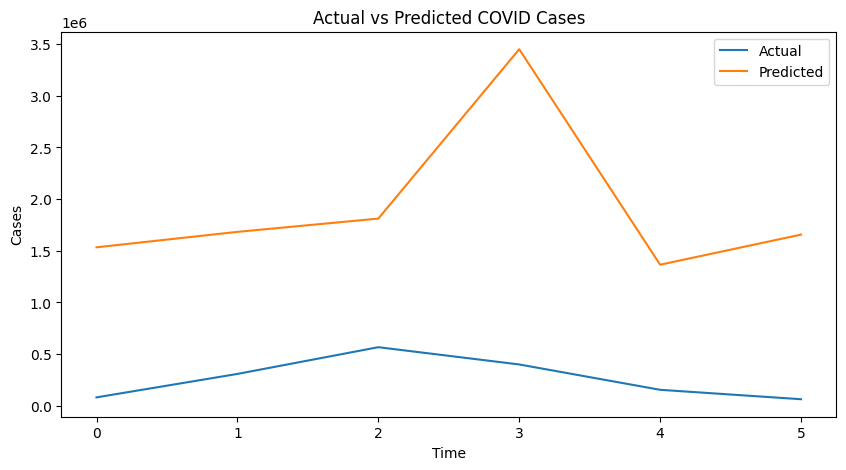

In [22]:
# STEP 16 : Plot
plt.figure(figsize = (10,5))
plt.plot(Y_test.values, label = "Actual")
plt.plot(Y_pred, label = "Predicted")

plt.legend()
plt.title("Actual vs Predicted COVID Cases")
plt.xlabel("Time")
plt.ylabel("Cases")
plt.show()

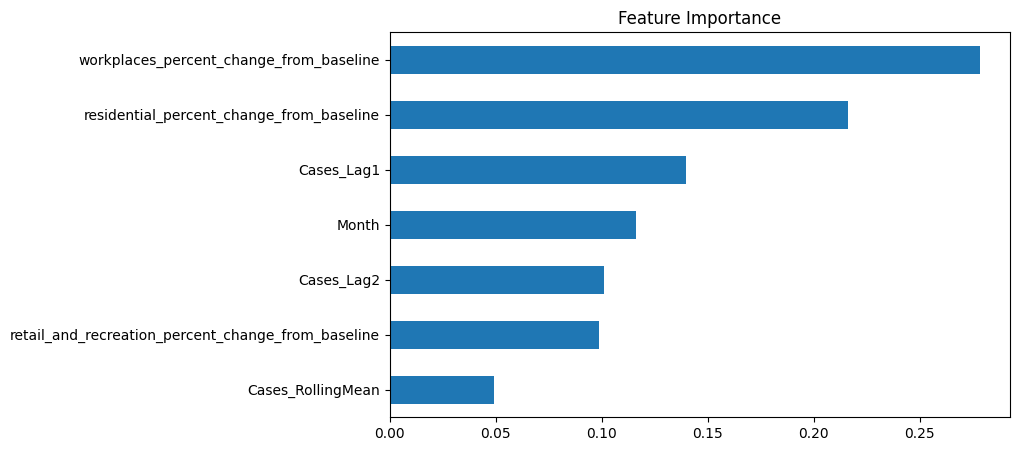

In [23]:
# STEP 17 : Feature Importance
feature_importance = pd.Series(model.feature_importances_, index = X.columns)
feature_importance.sort_values().plot(kind = "barh", figsize = (8,5))
plt.title("Feature Importance")
plt.show()